In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/notebooks/animeguylrn/us-accidents-eda/US Accidents Model-Free Processed Data.parquet
/kaggle/input/notebooks/animeguylrn/us-accidents-eda/__results__.html
/kaggle/input/notebooks/animeguylrn/us-accidents-eda/__notebook__.ipynb
/kaggle/input/notebooks/animeguylrn/us-accidents-eda/__output__.json
/kaggle/input/notebooks/animeguylrn/us-accidents-eda/custom.css


In [2]:
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
!pip install feature_engine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 2.0 MB/s eta 0:00:00


In [4]:
from sklearn import set_config

set_config(transform_output="pandas")

In [5]:
lf = pl.scan_parquet('/kaggle/input/notebooks/animeguylrn/us-accidents-eda/US Accidents Model-Free Processed Data.parquet')

df = (
    lf
    .collect()
    .to_pandas(use_pyarrow_extension_array=False)
)

del lf

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 42 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Source                 uint8         
 1   Severity               uint8         
 2   Start_Time             datetime64[us]
 3   End_Time               datetime64[us]
 4   Start_Lat              float64       
 5   Start_Lng              float64       
 6   End_Lat                float64       
 7   End_Lng                float64       
 8   Distance(mi)           float64       
 9   Street                 object        
 10  City                   object        
 11  County                 object        
 12  State                  object        
 13  Timezone               object        
 14  Temperature(F)         float64       
 15  Wind_Chill(F)          float64       
 16  Humidity(%)            float64       
 17  Pressure(in)           float64       
 18  Visibility(mi)        

In [7]:
categorical_columns = ['Street','City','County','State','Timezone','Wind_Direction','Weather_Condition']
datetime_columns = ['Start_Time','End_Time','Start_Date']
weather_columns = ['Temperature(F)','Wind_Chill(F)','Humidity(%)','Pressure(in)','Visibility(mi)','Wind_Speed(mph)','Precipitation(in)'] # Numerical Only For Now
light_cols = ['Sunrise_Sunset','Civil_Twilight','Nautical_Twilight','Astronomical_Twilight']

In [8]:
for col in categorical_columns:
    df[col] = df[col].astype('category')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 42 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Source                 uint8         
 1   Severity               uint8         
 2   Start_Time             datetime64[us]
 3   End_Time               datetime64[us]
 4   Start_Lat              float64       
 5   Start_Lng              float64       
 6   End_Lat                float64       
 7   End_Lng                float64       
 8   Distance(mi)           float64       
 9   Street                 category      
 10  City                   category      
 11  County                 category      
 12  State                  category      
 13  Timezone               category      
 14  Temperature(F)         float64       
 15  Wind_Chill(F)          float64       
 16  Humidity(%)            float64       
 17  Pressure(in)           float64       
 18  Visibility(mi)        

**Step 0 - Handeling Bad Data/Outliers**

Firstly, Lets see the weather data

In [10]:
df[weather_columns].describe()

,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,7.564541e+06,5.729375e+06,7.554250e+06,7.587715e+06,7.551296e+06,7.157161e+06,5.524808e+06
mean,6.166329e+01,5.825105e+01,6.483104e+01,2.953899e+01,9.090376e+00,7.685490e+00,8.407210e-03
std,1.901365e+01,2.238983e+01,2.282097e+01,1.006190e+00,2.688316e+00,5.424983e+00,1.102246e-01
min,-8.900000e+01,-8.900000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,4.900000e+01,4.300000e+01,4.800000e+01,2.937000e+01,1.000000e+01,4.600000e+00,0.000000e+00
50%,6.400000e+01,6.200000e+01,6.700000e+01,2.986000e+01,1.000000e+01,7.000000e+00,0.000000e+00
75%,7.600000e+01,7.500000e+01,8.400000e+01,3.003000e+01,1.000000e+01,1.040000e+01,0.000000e+00
max,2.070000e+02,2.070000e+02,1.000000e+02,5.863000e+01,1.400000e+02,1.087000e+03,3.647000e+01


Notice We have absurd data at places, we will see what to do with them

Physical Limits imposed -
* Temperature $\in [-60,130]$ $^{o}$F
* Humidity $\in [1,100]$ %
* Pressure $\in [25,32.5]$ in
* Visibility $\in [0,20]$ mi
* Wind Speed $\in [0,150]$ mph

In [11]:
invalid_weather = (
    (df["Temperature(F)"] < -60) |
    (df["Temperature(F)"] > 130) |

    (df["Humidity(%)"] < 1) |
    (df["Humidity(%)"] > 100) |

    (df["Pressure(in)"] < 25) |
    (df["Pressure(in)"] > 32.5) |

    (df["Visibility(mi)"] < 0) |
    (df["Visibility(mi)"] > 20) |

    (df["Wind_Speed(mph)"] < 0) |
    (df["Wind_Speed(mph)"] > 150)
)

bad_weather_rows = df[invalid_weather]

bad_weather_rows.shape

(105371, 42)

In [12]:
df[
    [
        "Temperature(F)",
        "Humidity(%)",
        "Pressure(in)",
        "Visibility(mi)",
        "Wind_Speed(mph)"
    ]
].quantile(
    [0.001, 0.01, 0.99, 0.999]
)

,Temperature(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph)
0.001,-7.0,6.0,22.70,0.0,0.0
0.010,12.2,12.0,24.58,0.5,0.0
0.990,96.0,100.0,30.44,10.0,23.0
0.999,105.1,100.0,30.67,30.0,31.1


Checking which feature contributes how much

In [13]:
WEATHER_LIMITS = {
    "Temperature(F)": (-60, 130),
    "Humidity(%)": (1, 100),
    "Pressure(in)": (25, 32.5),
    "Visibility(mi)": (0, 20),
    "Wind_Speed(mph)": (0, 150)
}

for column, (lower, upper) in WEATHER_LIMITS.items():

    invalid_mask = (
    df[column].notna()
    &
    ~df[column].between(lower, upper)
    )

    count = invalid_mask.sum()

    percentage = invalid_mask.mean() * 100

    print(
        f"{column:<20} "
        f"Invalid: {count:>8,} "
        f"({percentage:.4f}%)"
    )

Temperature(F)       Invalid:       65 (0.0008%)
Humidity(%)          Invalid:        0 (0.0000%)
Pressure(in)         Invalid:   97,297 (1.2590%)
Visibility(mi)       Invalid:   10,047 (0.1300%)
Wind_Speed(mph)      Invalid:       51 (0.0007%)


In [14]:
pressure = df["Pressure(in)"]
pressure.describe(
    percentiles=[0.001, 0.01, 0.05, 0.95, 0.99, 0.999]
)

count    7.587715e+06
mean     2.953899e+01
std      1.006190e+00
min      0.000000e+00
0.1%     2.270000e+01
1%       2.458000e+01
5%       2.798000e+01
50%      2.986000e+01
95%      3.026000e+01
99%      3.044000e+01
99.9%    3.067000e+01
max      5.863000e+01
Name: Pressure(in), dtype: float64

This suggests that the lower bound for pressure is too aggressive, we loose it a bit

In [15]:
invalid_weather = (
    (df["Temperature(F)"] < -60) |
    (df["Temperature(F)"] > 130) |

    (df["Humidity(%)"] < 1) |
    (df["Humidity(%)"] > 100) |

    (df["Pressure(in)"] < 20) |
    (df["Pressure(in)"] > 32.5) |

    (df["Visibility(mi)"] < 0) |
    (df["Visibility(mi)"] > 20) |

    (df["Wind_Speed(mph)"] < 0) |
    (df["Wind_Speed(mph)"] > 150)
)

bad_weather_rows = df[invalid_weather]

bad_weather_rows.shape

(10613, 42)

In [16]:
WEATHER_LIMITS = {
    "Temperature(F)": (-60, 130),
    "Humidity(%)": (1, 100),
    "Pressure(in)": (20, 32.5),
    "Visibility(mi)": (0, 20),
    "Wind_Speed(mph)": (0, 150)
}

for column, (lower, upper) in WEATHER_LIMITS.items():

    invalid_mask = (
    df[column].notna()
    &
    ~df[column].between(lower, upper)
    )

    count = invalid_mask.sum()

    percentage = invalid_mask.mean() * 100

    print(
        f"{column:<20} "
        f"Invalid: {count:>8,} "
        f"({percentage:.4f}%)"
    )

Temperature(F)       Invalid:       65 (0.0008%)
Humidity(%)          Invalid:        0 (0.0000%)
Pressure(in)         Invalid:      451 (0.0058%)
Visibility(mi)       Invalid:   10,047 (0.1300%)
Wind_Speed(mph)      Invalid:       51 (0.0007%)


In [17]:
visibility = df['Visibility(mi)']
visibility.describe(
    percentiles=[0.001, 0.01, 0.05, 0.95, 0.99, 0.999, 0.9999]
)

count     7.551296e+06
mean      9.090376e+00
std       2.688316e+00
min       0.000000e+00
0.1%      0.000000e+00
1%        5.000000e-01
5%        2.500000e+00
50%       1.000000e+01
95%       1.000000e+01
99%       1.000000e+01
99.9%     3.000000e+01
99.99%    7.000000e+01
max       1.400000e+02
Name: Visibility(mi), dtype: float64

This suggests that the upper bound for visibility is too aggressive, we loose it a bit

In [18]:
invalid_weather = (
    (df["Temperature(F)"] < -60) |
    (df["Temperature(F)"] > 130) |

    (df["Humidity(%)"] < 1) |
    (df["Humidity(%)"] > 100) |

    (df["Pressure(in)"] < 20) |
    (df["Pressure(in)"] > 32.5) |

    (df["Visibility(mi)"] < 0) |
    (df["Visibility(mi)"] > 35) |

    (df["Wind_Speed(mph)"] < 0) |
    (df["Wind_Speed(mph)"] > 150)
)

bad_weather_rows = df[invalid_weather]

bad_weather_rows.shape

(6311, 42)

In [19]:
WEATHER_LIMITS = {
    "Temperature(F)": (-60, 130),
    "Humidity(%)": (1, 100),
    "Pressure(in)": (20, 32.5),
    "Visibility(mi)": (0, 30),
    "Wind_Speed(mph)": (0, 150)
}

for column, (lower, upper) in WEATHER_LIMITS.items():

    invalid_mask = (
    df[column].notna()
    &
    ~df[column].between(lower, upper)
    )

    count = invalid_mask.sum()

    percentage = invalid_mask.mean() * 100

    print(
        f"{column:<20} "
        f"Invalid: {count:>8,} "
        f"({percentage:.4f}%)"
    )

Temperature(F)       Invalid:       65 (0.0008%)
Humidity(%)          Invalid:        0 (0.0000%)
Pressure(in)         Invalid:      451 (0.0058%)
Visibility(mi)       Invalid:    5,937 (0.0768%)
Wind_Speed(mph)      Invalid:       51 (0.0007%)


In [20]:
WEATHER_LIMITS = {
    "Temperature(F)": (-60, 130),
    "Humidity(%)": (1, 100),
    "Pressure(in)": (20, 32.5),
    "Visibility(mi)": (0, 35),
    "Wind_Speed(mph)": (0, 150)
}

for column, (lower, upper) in WEATHER_LIMITS.items():

    invalid_mask = (
    df[column].notna()
    &
    ~df[column].between(lower, upper)
    )

    count = invalid_mask.sum()

    percentage = invalid_mask.mean() * 100

    print(
        f"{column:<20} "
        f"Invalid: {count:>8,} "
        f"({percentage:.4f}%)"
    )

Temperature(F)       Invalid:       65 (0.0008%)
Humidity(%)          Invalid:        0 (0.0000%)
Pressure(in)         Invalid:      451 (0.0058%)
Visibility(mi)       Invalid:    5,745 (0.0743%)
Wind_Speed(mph)      Invalid:       51 (0.0007%)


This suggests Visibility is actually a bit too anomalous, we will look at the ditributions

<Axes: xlabel='Visibility(mi)', ylabel='Density'>

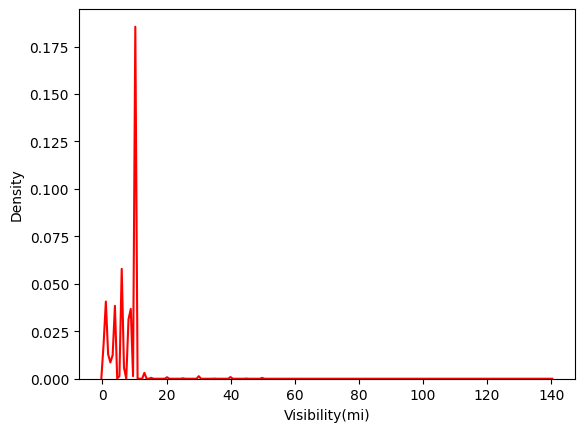

In [21]:
sns.kdeplot(df['Visibility(mi)'],color='red',label='Visibility')

<Axes: xlabel='Visibility(mi)', ylabel='Density'>

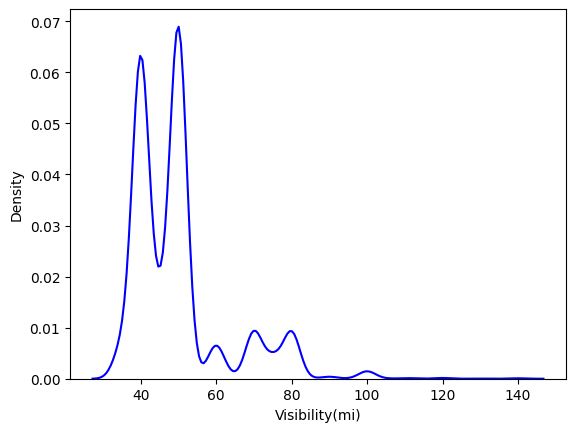

In [22]:
sns.kdeplot(df[df['Visibility(mi)'] > 30]['Visibility(mi)'], color = 'blue')

Visibility is indeed anomalous

Final Decided Limits to Impose -
* Temperature $\in [-60,130]$ $^{o}$F
* Humidity $\in [1,100]$ %
* Pressure $\in [20,32.5]$ in
* Visibility $\in [0,30]$ mi
* Wind Speed $\in [0,150]$ mph

In [23]:
'''Cleanup'''
del WEATHER_LIMITS
del invalid_weather
del bad_weather_rows
del invalid_mask
del pressure
del visibility

In [24]:
final_weather_filter = (
    (df["Temperature(F)"] < -60) |
    (df["Temperature(F)"] > 130) |

    (df["Humidity(%)"] < 1) |
    (df["Humidity(%)"] > 100) |

    (df["Pressure(in)"] < 20) |
    (df["Pressure(in)"] > 32.5) |

    (df["Visibility(mi)"] < 0) |
    (df["Visibility(mi)"] > 30) |

    (df["Wind_Speed(mph)"] < 0) |
    (df["Wind_Speed(mph)"] > 150)
)

df = df[~final_weather_filter]

del final_weather_filter

Now, Lets See the Time data

In [25]:
df['Start_Time'].describe()

count                       7721891
mean     2020-06-04 13:02:44.689739
min             2016-01-14 20:18:33
25%      2018-11-23 18:06:57.500000
50%             2020-11-11 16:22:00
75%             2022-01-20 09:49:53
max             2023-03-31 23:30:00
Name: Start_Time, dtype: object

In [26]:
from feature_engine.datetime import DatetimeFeatures

DTF = DatetimeFeatures(
    variables=['Start_Time','End_Time'],
    features_to_extract=['day_of_year','hour','year','weekend','leap_year']
)

dfT = DTF.fit_transform(df[['Start_Time','End_Time','Severity']])

del DTF

In [27]:
dfT.sample(2)

,Severity,Start_Time_day_of_year,Start_Time_hour,Start_Time_year,Start_Time_weekend,Start_Time_leap_year,End_Time_day_of_year,End_Time_hour,End_Time_year,End_Time_weekend,End_Time_leap_year
7244821,2,364,14,2019,0,0,364,15,2019,0,0
1871789,3,269,16,2019,0,0,269,17,2019,0,0


In [28]:
dfT.rename(columns={
    'Start_Time_day_of_year' : 'Accident Day',
    'Start_Time_hour' : 'Accident Timing',
    'Start_Time_year' : 'Accident Year',
    'End_Time_day_of_year' : 'End',
    'End_Time_hour' : 'Resolution Time',
    'Start_Time_weekend' : 'Weekend'
},inplace=True)

year_diff = dfT['End_Time_year'] - dfT['Accident Year']

days_in_year = np.where(
    dfT['Start_Time_leap_year'],
    366,
    365
)

dfT['Days To Resolve'] = np.select(
    [
        year_diff < 0,      # impossible
        year_diff == 0,     # same year
        year_diff == 1,     # crossed New Year
        year_diff > 1       # impossible
    ],
    [
        -1,
        dfT['End'] - dfT['Accident Day'],
        days_in_year - dfT['Accident Day'] + dfT['End'],
        -1
    ]
)

dfT.drop(columns=['End_Time_year','End_Time_weekend','End','Start_Time_leap_year','End_Time_leap_year'],inplace=True)

del days_in_year
del year_diff

In [29]:
if ((dfT['Days To Resolve'] <= -1).any()):
    print('Illogical Data')

Illogical Data


In [30]:
dfT[dfT['Days To Resolve'] <= -1]['Days To Resolve'].count()

np.int64(140)

In [31]:
dfT = dfT[dfT['Days To Resolve'] > -1]

In [32]:
with pd.option_context('display.max_rows', None):
    print(dfT['Days To Resolve'].value_counts().sort_index())

Days To Resolve
0      7334709
1       373496
2         3923
3         1349
4          927
5          348
6          218
7          409
8          158
9          138
10          85
11          91
12          56
13          74
14          58
15          67
16          38
17          19
18          10
19          26
20          22
21          29
22          31
23           9
24          12
25          28
26           7
27          19
28          26
29          26
30          19
31          28
32          20
33          19
34          19
35          15
36           9
37          17
38          15
39          37
40          17
41          17
42          26
43           4
44          22
45          23
46          13
47          17
48          17
49          20
50           4
51          23
52          11
53          10
54           8
55           8
56           9
57          17
58           8
59           7
60           9
61           8
62          18
63          10
64          11
65       

In [33]:
dfT['Days To Resolve'].describe(percentiles=[
    .90, .95, .99, .995, .999
])

count    7.721751e+06
mean     2.650530e-01
std      8.632048e+00
min      0.000000e+00
50%      0.000000e+00
90%      0.000000e+00
95%      1.000000e+00
99%      1.000000e+00
99.5%    1.000000e+00
99.9%    4.000000e+00
max      6.640000e+02
Name: Days To Resolve, dtype: float64

In [34]:
dfT[dfT['Days To Resolve'].between(7,31)].corr()

,Severity,Accident Day,Accident Timing,Accident Year,Weekend,Resolution Time,Days To Resolve
Severity,1.000000,-0.026347,-0.050330,-0.220248,-0.045782,-0.012446,0.054433
Accident Day,-0.026347,1.000000,0.089771,-0.199233,0.013907,-0.125825,-0.029983
Accident Timing,-0.050330,0.089771,1.000000,-0.090852,0.043369,-0.103963,0.046181
Accident Year,-0.220248,-0.199233,-0.090852,1.000000,-0.037978,0.132813,-0.186069
Weekend,-0.045782,0.013907,0.043369,-0.037978,1.000000,0.087118,-0.004283
Resolution Time,-0.012446,-0.125825,-0.103963,0.132813,0.087118,1.000000,-0.079757
Days To Resolve,0.054433,-0.029983,0.046181,-0.186069,-0.004283,-0.079757,1.000000


In [35]:
del dfT

Severity and Days To Resolve have low correlation, so we really cannot tie them together.

We will drop all the anomalous data

In [36]:
from feature_engine.datetime import DatetimeFeatures

DTF = DatetimeFeatures(
        variables=['Start_Time','End_Time'],
    features_to_extract=['day_of_year','hour','year','leap_year'],
    drop_original=True
)

df = DTF.fit_transform(df)

del DTF

df.rename(columns={
    'Start_Time_day_of_year' : 'Accident Day',
    'Start_Time_hour' : 'Accident Timing',
    'Start_Time_year' : 'Accident Year',
    'End_Time_day_of_year' : 'End',
    'End_Time_hour' : 'Resolution Time'
},inplace=True)

year_diff = df['End_Time_year'] - df['Accident Year']

days_in_year = np.where(
    df['Start_Time_leap_year'],
    366,
    365
)

df['Days To Resolve'] = np.select(
    [
        year_diff < 0,      # impossible
        year_diff == 0,     # same year
        year_diff == 1,     # crossed New Year
        year_diff > 1       # impossible
    ],
    [
        -1,
        df['End'] - df['Accident Day'],
        days_in_year - df['Accident Day'] + df['End'],
        -1
    ]
)

df.drop(columns=['End_Time_year','End','Start_Time_leap_year','End_Time_leap_year'],inplace=True)

del days_in_year
del year_diff

filter_mask = (
    df['Days To Resolve'] > 7
)

df = df[~filter_mask]

del filter_mask

In [37]:
from feature_engine.datetime import DatetimeOrdinal

DTO = DatetimeOrdinal(
    variables='Start_Date',
    start_date=df['Start_Date'].min(),
    drop_original=True
)

df = DTO.fit_transform(df)

del DTO

In [38]:
df.rename(columns={'Start_Date_ordinal' : 'Start_Day_Ordinal'},inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7715519 entries, 0 to 7728393
Data columns (total 45 columns):
 #   Column                 Dtype   
---  ------                 -----   
 0   Source                 uint8   
 1   Severity               uint8   
 2   Start_Lat              float64 
 3   Start_Lng              float64 
 4   End_Lat                float64 
 5   End_Lng                float64 
 6   Distance(mi)           float64 
 7   Street                 category
 8   City                   category
 9   County                 category
 10  State                  category
 11  Timezone               category
 12  Temperature(F)         float64 
 13  Wind_Chill(F)          float64 
 14  Humidity(%)            float64 
 15  Pressure(in)           float64 
 16  Visibility(mi)         float64 
 17  Wind_Direction         category
 18  Wind_Speed(mph)        float64 
 19  Precipitation(in)      float64 
 20  Weather_Condition      category
 21  Amenity                bool    
 22 

Now the location data,
This is as I have read in the document and from my research online is the most weird

Only, One identifier of location is needed. We will keep county as it is big enough but not too big geographically.

In [39]:
df.drop(columns=['Start_Lng','End_Lng','Start_Lat','End_Lat','Distance(mi)','Street','City','State','Timezone'],inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7715519 entries, 0 to 7728393
Data columns (total 36 columns):
 #   Column                 Dtype   
---  ------                 -----   
 0   Source                 uint8   
 1   Severity               uint8   
 2   County                 category
 3   Temperature(F)         float64 
 4   Wind_Chill(F)          float64 
 5   Humidity(%)            float64 
 6   Pressure(in)           float64 
 7   Visibility(mi)         float64 
 8   Wind_Direction         category
 9   Wind_Speed(mph)        float64 
 10  Precipitation(in)      float64 
 11  Weather_Condition      category
 12  Amenity                bool    
 13  Bump                   bool    
 14  Crossing               bool    
 15  Give_Way               bool    
 16  Junction               bool    
 17  No_Exit                bool    
 18  Railway                bool    
 19  Roundabout             bool    
 20  Station                bool    
 21  Stop                   bool    
 22 

**Step 1 - Handeling Nulls**

In [40]:
'''Precentage of Data Missing'''

100*(df.isna().sum())/77_00_000

Source                    0.000000
Severity                  0.000000
County                    0.000000
Temperature(F)            2.122571
Wind_Chill(F)            25.910403
Humidity(%)               2.255909
Pressure(in)              1.825727
Visibility(mi)            2.297390
Wind_Direction            2.271325
Wind_Speed(mph)           7.404312
Precipitation(in)        28.555922
Weather_Condition         2.250532
Amenity                   0.000000
Bump                      0.000000
Crossing                  0.000000
Give_Way                  0.000000
Junction                  0.000000
No_Exit                   0.000000
Railway                   0.000000
Roundabout                0.000000
Station                   0.000000
Stop                      0.000000
Traffic_Calming           0.000000
Traffic_Signal            0.000000
Sunrise_Sunset            0.299844
Civil_Twilight            0.299844
Nautical_Twilight         0.299844
Astronomical_Twilight     0.299844
Start_Hour          

**We will test and use Mean/Median Imputation for features with about 5% data missing**

In [41]:
def SimpleImputeColumn(*,df,column,save_image=False):
    from sklearn.impute import SimpleImputer
    plt.figure(figsize=(16,9))

    original = df[f'{column}']
    sns.kdeplot(original,label='Original',color='red')
    
    mean_imputed = SimpleImputer(strategy='mean').fit_transform(df[[column]]).squeeze()
    sns.kdeplot(mean_imputed,label='Mean Imputed',color='blue')
    
    median_imputed = SimpleImputer(strategy='median').fit_transform(df[[column]]).squeeze()
    sns.kdeplot(median_imputed,label='Median Imputed',color='orange')
    
    plt.legend()
    if save_image:
        plt.savefig(f'{column} Imputations')
    plt.show()

    print(f'''
    Mean:
    OG : {original.mean()}
    Mean : {mean_imputed.mean()}
    Median : {median_imputed.mean()}
    ''')
    print(f'''
    Median:
    OG : {original.median()}
    Mean : {mean_imputed.median()}
    Median : {median_imputed.median()}
    ''')
    print(f'''
    Std:
    OG : {original.std()}
    Mean : {mean_imputed.std()}
    Median : {median_imputed.std()}
    ''')
    print(f'''
    Var:
    OG : {original.var()}
    Mean : {mean_imputed.var()}
    Median : {median_imputed.var()}
    ''')

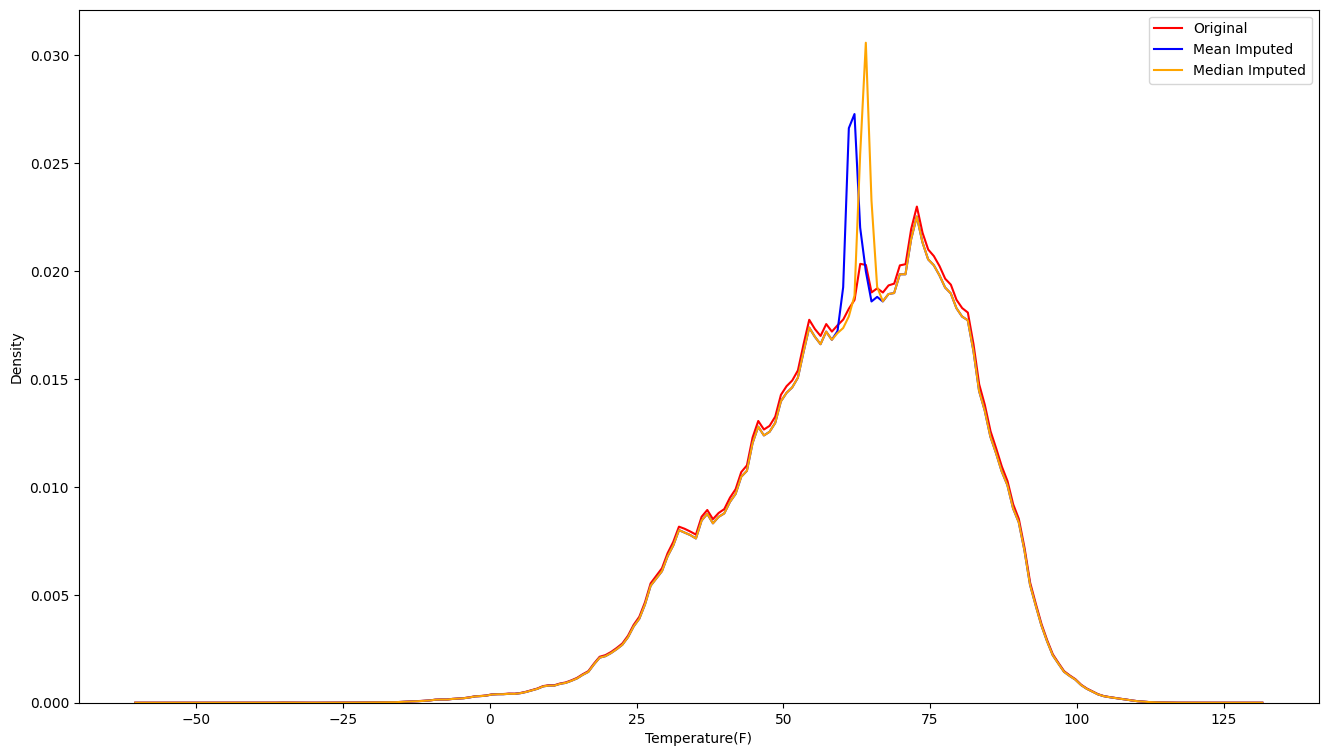


    Mean:
    OG : 61.66309104735502
    Mean : 61.663091047355046
    Median : 61.71259383847023
    

    Median:
    OG : 64.0
    Mean : 63.0
    Median : 64.0
    

    Std:
    OG : 19.009802661357995
    Mean : 18.807382405909078
    Median : 18.81039249907366
    

    Var:
    OG : 361.37259722377354
    Mean : 353.7176329620984
    Median : 353.8308659692067
    


In [42]:
SimpleImputeColumn(df=df,column='Temperature(F)')

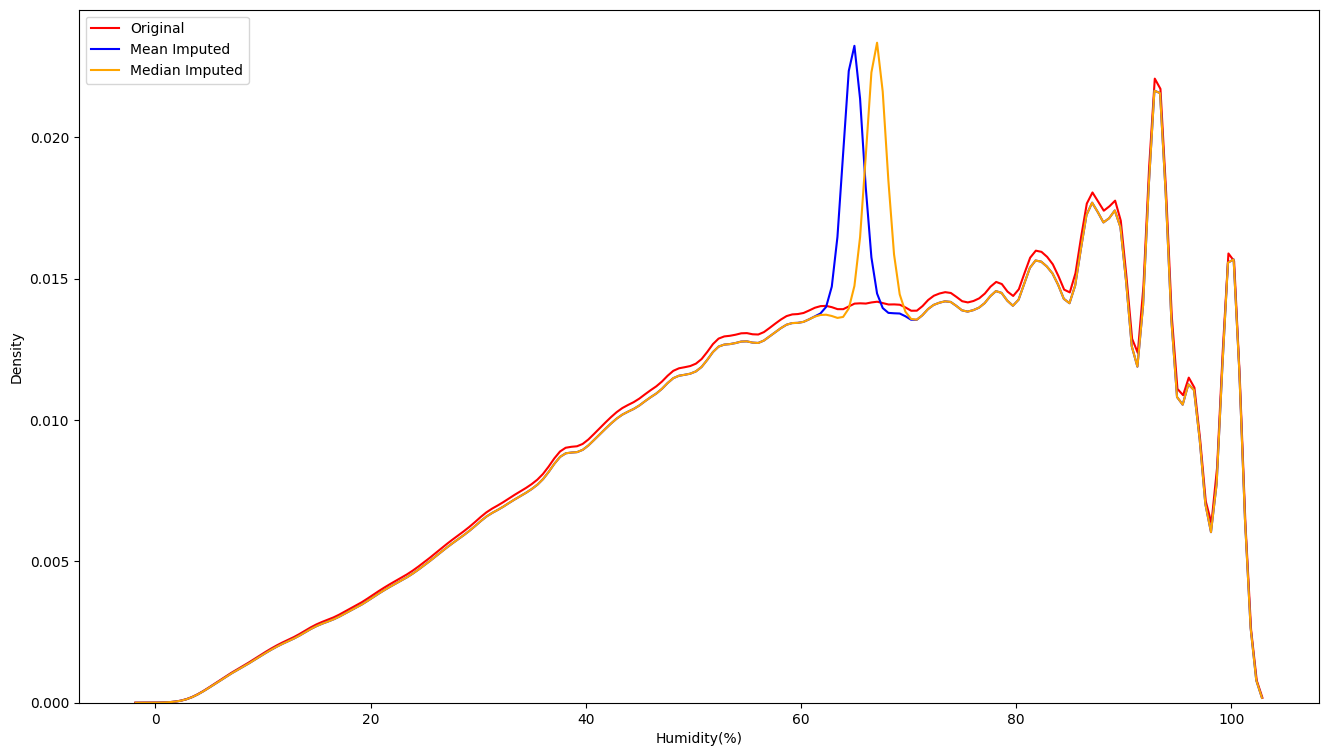


    Mean:
    OG : 64.84991687676201
    Mean : 64.84991687676205
    Median : 64.89832323658331
    

    Median:
    OG : 67.0
    Mean : 66.0
    Median : 67.0
    

    Std:
    OG : 22.80796011384571
    Mean : 22.549752541196774
    Median : 22.55200820786213
    

    Var:
    OG : 520.2030445547767
    Mean : 508.49133966921045
    Median : 508.5930742074808
    


In [43]:
SimpleImputeColumn(df=df,column='Humidity(%)')

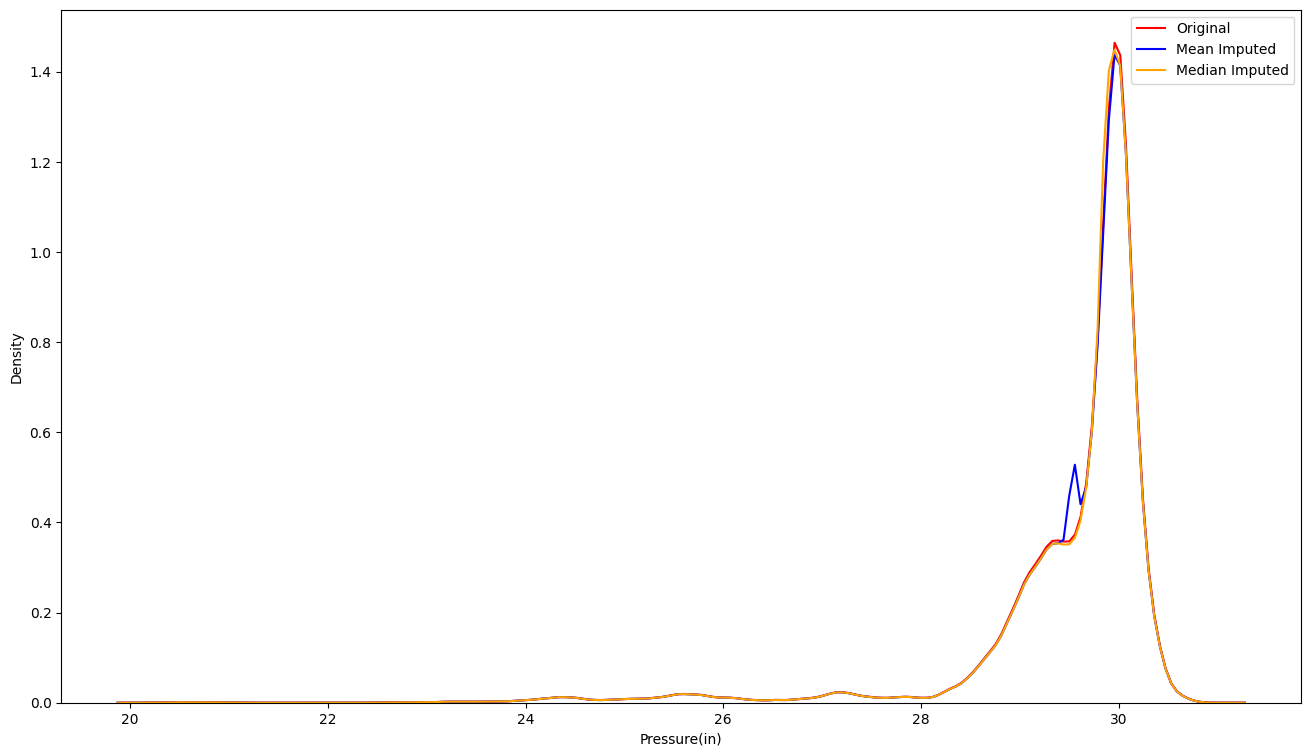


    Mean:
    OG : 29.539738821624688
    Mean : 29.53973882162465
    Median : 29.54557415645009
    

    Median:
    OG : 29.86
    Mean : 29.85
    Median : 29.86
    

    Std:
    OG : 0.99904629207362
    Mean : 0.989902863370021
    Median : 0.9908291776197781
    

    Var:
    OG : 0.9980934937060488
    Mean : 0.9799076789081664
    Median : 0.9817424592226858
    


In [44]:
SimpleImputeColumn(df=df,column='Pressure(in)')

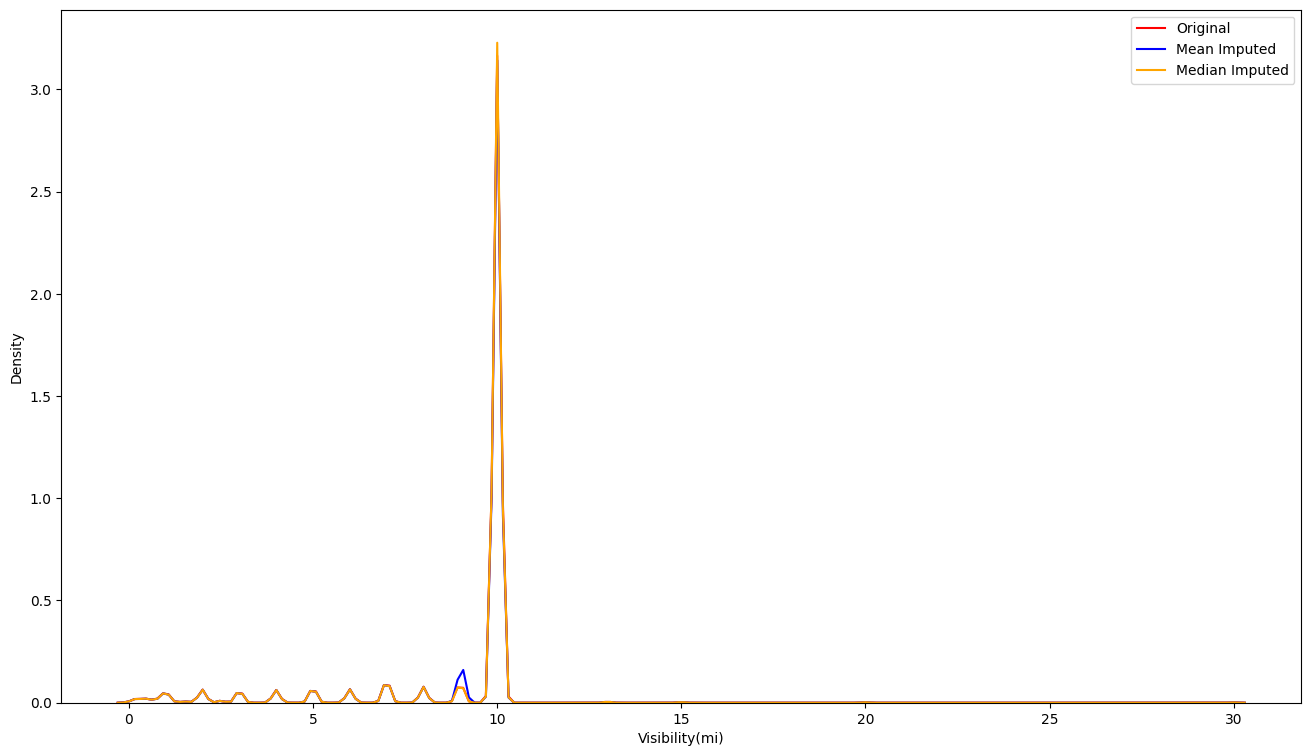


    Mean:
    OG : 9.058499109916664
    Mean : 9.05849910991667
    Median : 9.080085547064291
    

    Median:
    OG : 10.0
    Mean : 10.0
    Median : 10.0
    

    Std:
    OG : 2.40744391474115
    Mean : 2.379685318895777
    Median : 2.3838540002539057
    

    Var:
    OG : 5.7957862026241935
    Mean : 5.662902216968096
    Median : 5.682759894526548
    


In [45]:
SimpleImputeColumn(df=df,column='Visibility(mi)')

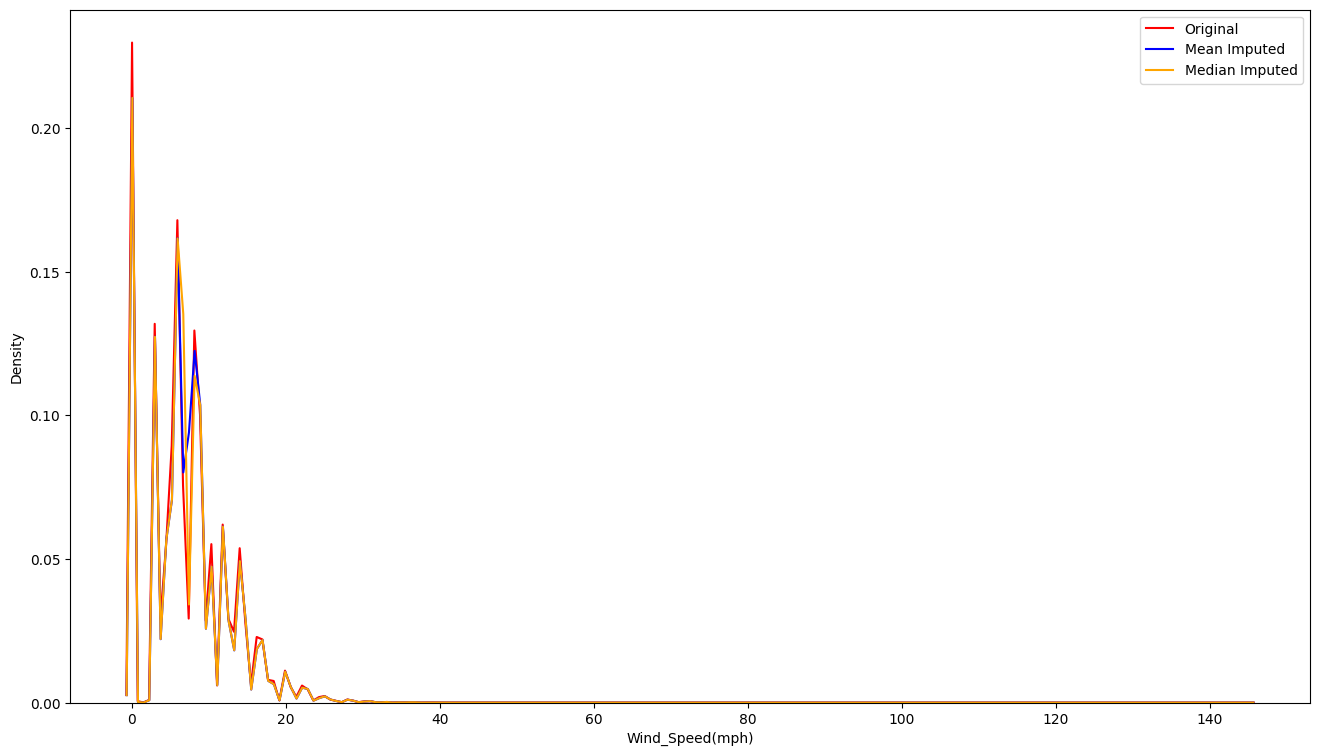


    Mean:
    OG : 7.681702138736505
    Mean : 7.681702138736506
    Median : 7.631328313753102
    

    Median:
    OG : 7.0
    Mean : 7.681702138736505
    Median : 7.0
    

    Std:
    OG : 5.277213959230837
    Mean : 5.078494723097225
    Median : 5.081624846282678
    

    Var:
    OG : 27.848987171500802
    Mean : 25.791108652526354
    Median : 25.822911078357453
    


In [46]:
SimpleImputeColumn(df=df,column='Wind_Speed(mph)')

**Wind Chill**

In the US, the Wind Chill Index for the Fahrenheit scale is defined as follows-

**$T_{WCI} = 35.74 + 0.6215 T_{Air} - 35.75 v_{Wind}^{0.16} + 0.4275 T_{Air} v_{Wind}^{0.16}$**

Reference (US Weather.gov) - https://www.weather.gov/ctp/ChillHeat

That is, The WCI is actually a Formula of the form-

**$T_{WCI} = c_{0} + c_{1} T_{Air} + c_{2} v_{Wind}^{0.16} + c_{3} T_{Air} v_{Wind}^{0.16}$**

A Regression check would prove if this is true, in which case we can drop the WCI all-together as it is repeated information.

In [47]:
from sklearn.impute import SimpleImputer

si = SimpleImputer(strategy='median')
df[['Temperature(F)','Wind_Speed(mph)','Humidity(%)','Pressure(in)','Visibility(mi)']] = si.fit_transform(
    df[['Temperature(F)','Wind_Speed(mph)','Humidity(%)','Pressure(in)','Visibility(mi)']]
)

In [48]:
del si

In [49]:
100*(df.isna().sum())/77_00_000

Source                    0.000000
Severity                  0.000000
County                    0.000000
Temperature(F)            0.000000
Wind_Chill(F)            25.910403
Humidity(%)               0.000000
Pressure(in)              0.000000
Visibility(mi)            0.000000
Wind_Direction            2.271325
Wind_Speed(mph)           0.000000
Precipitation(in)        28.555922
Weather_Condition         2.250532
Amenity                   0.000000
Bump                      0.000000
Crossing                  0.000000
Give_Way                  0.000000
Junction                  0.000000
No_Exit                   0.000000
Railway                   0.000000
Roundabout                0.000000
Station                   0.000000
Stop                      0.000000
Traffic_Calming           0.000000
Traffic_Signal            0.000000
Sunrise_Sunset            0.299844
Civil_Twilight            0.299844
Nautical_Twilight         0.299844
Astronomical_Twilight     0.299844
Start_Hour          

In [50]:
dfWCI = df[['Temperature(F)','Wind_Speed(mph)','Wind_Chill(F)']].copy()

In [51]:
def actual_wind_chill(temp, speed):
    return (
        35.74
        + 0.6215 * temp
        - 35.75 * (speed ** 0.16)
        + 0.4275 * temp * (speed ** 0.16)
    )

In [52]:
valid_mask = (
    (df["Temperature(F)"] <= 50) &
    (df["Wind_Speed(mph)"] > 3)
)

mask = (
    dfWCI["Wind_Chill(F)"].notna()
    & valid_mask
)

actual = dfWCI.loc[mask, "Wind_Chill(F)"]

predicted = actual_wind_chill(
    dfWCI.loc[mask, "Temperature(F)"],
    dfWCI.loc[mask, "Wind_Speed(mph)"]
)

from sklearn.metrics import (
    mean_absolute_error,
    r2_score
)

print("MAE:", mean_absolute_error(actual, predicted))
print("R2 :", r2_score(actual, predicted))

MAE: 0.3793792584827617
R2 : 0.9964852639269342


In [53]:
dfWCI.describe()

,Temperature(F),Wind_Speed(mph),Wind_Chill(F)
count,7.715519e+06,7.715519e+06,5.720418e+06
mean,6.171259e+01,7.631328e+00,5.825053e+01
std,1.881039e+01,5.081625e+00,2.238816e+01
min,-5.800000e+01,0.000000e+00,-8.000000e+01
25%,5.000000e+01,5.000000e+00,4.300000e+01
50%,6.400000e+01,7.000000e+00,6.200000e+01
75%,7.600000e+01,1.000000e+01,7.500000e+01
max,1.292000e+02,1.450000e+02,1.280000e+02


In [54]:
'''Cleanup'''

del dfWCI
del predicted
del valid_mask
del actual
del mask

In [55]:
df.drop(columns=['Wind_Chill(F)'],inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7715519 entries, 0 to 7728393
Data columns (total 35 columns):
 #   Column                 Dtype   
---  ------                 -----   
 0   Source                 uint8   
 1   Severity               uint8   
 2   County                 category
 3   Temperature(F)         float64 
 4   Humidity(%)            float64 
 5   Pressure(in)           float64 
 6   Visibility(mi)         float64 
 7   Wind_Direction         category
 8   Wind_Speed(mph)        float64 
 9   Precipitation(in)      float64 
 10  Weather_Condition      category
 11  Amenity                bool    
 12  Bump                   bool    
 13  Crossing               bool    
 14  Give_Way               bool    
 15  Junction               bool    
 16  No_Exit                bool    
 17  Railway                bool    
 18  Roundabout             bool    
 19  Station                bool    
 20  Stop                   bool    
 21  Traffic_Calming        bool    
 22 

In [56]:
100*(df.isna().sum())/77_00_000

Source                    0.000000
Severity                  0.000000
County                    0.000000
Temperature(F)            0.000000
Humidity(%)               0.000000
Pressure(in)              0.000000
Visibility(mi)            0.000000
Wind_Direction            2.271325
Wind_Speed(mph)           0.000000
Precipitation(in)        28.555922
Weather_Condition         2.250532
Amenity                   0.000000
Bump                      0.000000
Crossing                  0.000000
Give_Way                  0.000000
Junction                  0.000000
No_Exit                   0.000000
Railway                   0.000000
Roundabout                0.000000
Station                   0.000000
Stop                      0.000000
Traffic_Calming           0.000000
Traffic_Signal            0.000000
Sunrise_Sunset            0.299844
Civil_Twilight            0.299844
Nautical_Twilight         0.299844
Astronomical_Twilight     0.299844
Start_Hour                0.000000
End_Hour            

In [57]:
df[df['Precipitation(in)'].isna()].shape

(2198806, 35)

In [58]:
df['Precipitation(in)'].value_counts()

Precipitation(in)
0.00    4984090
0.01     150865
0.02      73962
0.03      49990
0.04      37271
         ...   
1.91          1
2.85          1
8.80          1
2.27          1
2.10          1
Name: count, Length: 299, dtype: int64

In [59]:
def HeavyImputeColumn(*,subset,target_column,n_neighbors=5,weights='uniform',max_iter=10,save_image=False):
    from sklearn.experimental import enable_iterative_imputer
    from sklearn.impute import KNNImputer, IterativeImputer
    from sklearn.preprocessing import StandardScaler
    plt.figure(figsize=(16,9))

    scaled = StandardScaler().fit_transform(subset)
    
    original = scaled[f'{target_column}']
    sns.kdeplot(original,label='Original',color='red')
    
    knn_imputed = KNNImputer(n_neighbors=n_neighbors,weights=weights).fit_transform(scaled)
    sns.kdeplot(knn_imputed[target_column],label='KNN Imputed',color='green')

    mice_imputed = IterativeImputer(max_iter=max_iter,initial_strategy='median').fit_transform(scaled)
    sns.kdeplot(mice_imputed[target_column],label='MICE Imputed',color='blue')
    
    plt.legend()
    if save_image:
        plt.savefig(f"{target_column}'s Heavy Imputations")
    plt.show()

    print(f'''
    Mean:
    OG : {original.mean()}
    KNN : {knn_imputed.mean()}
    MICE : {mice_imputed.mean()}
    ''')
    print(f'''
    Median:
    OG : {original.median()}
    KNN : {knn_imputed.median()}
    MICE : {mice_imputed.median()}
    ''')
    print(f'''
    Std:
    OG : {original.std()}
    KNN : {knn_imputed.std()}
    MICE : {mice_imputed.std()}
    ''')
    print(f'''
    Var:
    OG : {original.var()}
    KNN : {knn_imputed.var()}
    MICE : {mice_imputed.var()}
    ''')

<Axes: xlabel='Precipitation(in)', ylabel='Density'>

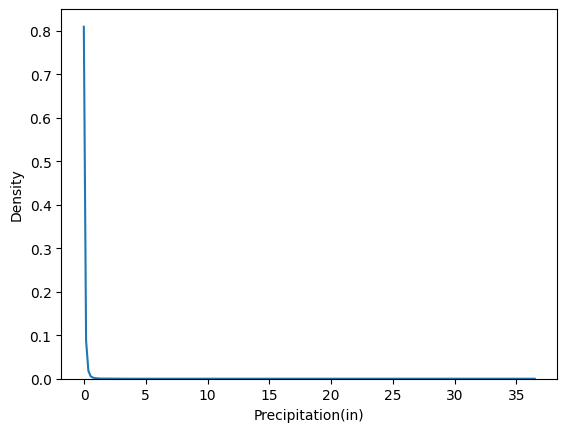

In [60]:
sns.kdeplot(df['Precipitation(in)'])

Precipitation is too skewed and ill-sitributed to impute, we will do feature selection to determine purpose.

Missing Indicator added for now

In [61]:
from feature_engine.imputation import AddMissingIndicator

df = AddMissingIndicator(variables=['Precipitation(in)']).fit_transform(df)

df.fillna({'Precipitation(in)':0},inplace=True)

df.rename(columns={'Precipitation(in)_na' : 'Precipitation Missing'},inplace=True)

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7715519 entries, 0 to 7728393
Data columns (total 36 columns):
 #   Column                 Dtype   
---  ------                 -----   
 0   Source                 uint8   
 1   Severity               uint8   
 2   County                 category
 3   Temperature(F)         float64 
 4   Humidity(%)            float64 
 5   Pressure(in)           float64 
 6   Visibility(mi)         float64 
 7   Wind_Direction         category
 8   Wind_Speed(mph)        float64 
 9   Precipitation(in)      float64 
 10  Weather_Condition      category
 11  Amenity                bool    
 12  Bump                   bool    
 13  Crossing               bool    
 14  Give_Way               bool    
 15  Junction               bool    
 16  No_Exit                bool    
 17  Railway                bool    
 18  Roundabout             bool    
 19  Station                bool    
 20  Stop                   bool    
 21  Traffic_Calming        bool    
 22 

Arbitrary Impute Wind_Direction & Weather_Condition to Missing

In [63]:
from sklearn.impute import SimpleImputer

si = SimpleImputer(strategy='constant',fill_value='Missing')

df[['Wind_Direction','Weather_Condition']] = si.fit_transform(df[['Wind_Direction','Weather_Condition']])

del si

In [64]:
100*(df.isna().sum())/77_00_000

Source                   0.000000
Severity                 0.000000
County                   0.000000
Temperature(F)           0.000000
Humidity(%)              0.000000
Pressure(in)             0.000000
Visibility(mi)           0.000000
Wind_Direction           0.000000
Wind_Speed(mph)          0.000000
Precipitation(in)        0.000000
Weather_Condition        0.000000
Amenity                  0.000000
Bump                     0.000000
Crossing                 0.000000
Give_Way                 0.000000
Junction                 0.000000
No_Exit                  0.000000
Railway                  0.000000
Roundabout               0.000000
Station                  0.000000
Stop                     0.000000
Traffic_Calming          0.000000
Traffic_Signal           0.000000
Sunrise_Sunset           0.299844
Civil_Twilight           0.299844
Nautical_Twilight        0.299844
Astronomical_Twilight    0.299844
Start_Hour               0.000000
End_Hour                 0.000000
Accident Day  

For the Light columns, the values being exactly equal is suspecious.
Lets do a quick pair-wise occurance check

In [65]:
mask_equal = (
    (df['Sunrise_Sunset'].isna() == df['Civil_Twilight'].isna()) &
    (df['Civil_Twilight'].isna() == df['Nautical_Twilight'].isna()) &
    (df['Nautical_Twilight'].isna() == df['Astronomical_Twilight'].isna())
)

(~mask_equal).sum()

np.int64(0)

This Means That every missing value occurs together, we have ~0.3 data missing.

That is ~23,000 rows missing. We can simply arbitray impute to 'Missing'.

In [66]:
df[light_cols].sample(2)

,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
7644705,Day,Day,Day,Day
3118272,Day,Day,Day,Day


In [67]:
from sklearn.impute import SimpleImputer

si = SimpleImputer(strategy='constant',fill_value='Missing')

df[light_cols] = df[light_cols].replace({None:np.nan})

df[light_cols] = si.fit_transform(df[light_cols])

del si

In [68]:
df[light_cols].sample(20)

,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
4260527,Night,Night,Night,Day
633529,Day,Day,Day,Day
6383762,Day,Day,Day,Day
6174590,Day,Day,Day,Day
4173566,Day,Day,Day,Day
2980286,Day,Day,Day,Day
3416720,Day,Day,Day,Day
2114595,Day,Day,Day,Day
1706676,Day,Day,Day,Day
4346943,Night,Day,Day,Day


In [69]:
df[light_cols].value_counts(dropna=False)

Sunrise_Sunset  Civil_Twilight  Nautical_Twilight  Astronomical_Twilight
Day             Day             Day                Day                      5319810
Night           Night           Night              Night                    1319431
                                Day                Day                       379625
                Day             Day                Day                       360442
                Night           Night              Day                       307045
Missing         Missing         Missing            Missing                    23088
Day             Day             Day                Night                       5418
Night           Night           Day                Night                        349
                Day             Day                Night                        231
Day             Night           Day                Day                           52
                                                   Night                         28
Nam

In [70]:
df['Illumination'] = np.select(
    [
        # Missing
        df[light_cols].isna().all(axis=1),

        # Day
        (
            (df['Sunrise_Sunset'] == 'Day') &
            (df['Civil_Twilight'] == 'Day') &
            (df['Nautical_Twilight'] == 'Day') &
            (df['Astronomical_Twilight'] == 'Day')
        ),

        # Civil Twilight
        (
            (df['Sunrise_Sunset'] == 'Night') &
            (df['Civil_Twilight'] == 'Day') &
            (df['Nautical_Twilight'] == 'Day') &
            (df['Astronomical_Twilight'] == 'Day')
        ),

        # Nautical Twilight
        (
            (df['Sunrise_Sunset'] == 'Night') &
            (df['Civil_Twilight'] == 'Night') &
            (df['Nautical_Twilight'] == 'Day') &
            (df['Astronomical_Twilight'] == 'Day')
        ),

        # Astronomical Twilight
        (
            (df['Sunrise_Sunset'] == 'Night') &
            (df['Civil_Twilight'] == 'Night') &
            (df['Nautical_Twilight'] == 'Night') &
            (df['Astronomical_Twilight'] == 'Day')
        ),

        # Night
        (
            (df['Sunrise_Sunset'] == 'Night') &
            (df['Civil_Twilight'] == 'Night') &
            (df['Nautical_Twilight'] == 'Night') &
            (df['Astronomical_Twilight'] == 'Night')
        )
    ],
    [
        'Missing',
        'Day',
        'Civil Twilight',
        'Nautical Twilight',
        'Astronomical Twilight',
        'Night'
    ],

    # Any invalid combination
    default='Missing'
)

In [71]:
df['Illumination'].value_counts(dropna=False)

Illumination
Day                      5319810
Night                    1319431
Nautical Twilight         379625
Civil Twilight            360442
Astronomical Twilight     307045
Missing                    29166
Name: count, dtype: int64

In [72]:
100*(df.isna().sum())/77_00_000

Source                   0.0
Severity                 0.0
County                   0.0
Temperature(F)           0.0
Humidity(%)              0.0
Pressure(in)             0.0
Visibility(mi)           0.0
Wind_Direction           0.0
Wind_Speed(mph)          0.0
Precipitation(in)        0.0
Weather_Condition        0.0
Amenity                  0.0
Bump                     0.0
Crossing                 0.0
Give_Way                 0.0
Junction                 0.0
No_Exit                  0.0
Railway                  0.0
Roundabout               0.0
Station                  0.0
Stop                     0.0
Traffic_Calming          0.0
Traffic_Signal           0.0
Sunrise_Sunset           0.0
Civil_Twilight           0.0
Nautical_Twilight        0.0
Astronomical_Twilight    0.0
Start_Hour               0.0
End_Hour                 0.0
Accident Day             0.0
Accident Timing          0.0
Accident Year            0.0
Resolution Time          0.0
Days To Resolve          0.0
Start_Day_Ordi

No More Values required to impute

**Imputation Decisions**

* Temperature -> Median Imputation is Good
* Wind Chill -> Has been dropped, it was repeated Information
* Humidity -> Median Imputation is Good
* Pressure -> Median Imputation is Good
* Visibility -> Median Imputation is Good
* Wind Speed -> Median Imputation is Good
* Precipitation -> Arbitrary Imputed to Zero
* Wind Direction -> Arbitrary Imputed to 'Missing'
* Weather Condition -> Arbitrary Imputed to 'Missing'
* Sunrise_Sunset -> Arbitrary Imputed to 'Missing'
* Civil_Twilight -> Arbitrary Imputed to 'Missing'
* Nautical_Twilight -> Arbitrary Imputed to 'Missing'
* Astronomical_Twilight -> Arbitrary Imputed to 'Missing'

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7715519 entries, 0 to 7728393
Data columns (total 37 columns):
 #   Column                 Dtype   
---  ------                 -----   
 0   Source                 uint8   
 1   Severity               uint8   
 2   County                 category
 3   Temperature(F)         float64 
 4   Humidity(%)            float64 
 5   Pressure(in)           float64 
 6   Visibility(mi)         float64 
 7   Wind_Direction         object  
 8   Wind_Speed(mph)        float64 
 9   Precipitation(in)      float64 
 10  Weather_Condition      object  
 11  Amenity                bool    
 12  Bump                   bool    
 13  Crossing               bool    
 14  Give_Way               bool    
 15  Junction               bool    
 16  No_Exit                bool    
 17  Railway                bool    
 18  Roundabout             bool    
 19  Station                bool    
 20  Stop                   bool    
 21  Traffic_Calming        bool    
 22 

**Finally I do a proper re-cleaning and Sink to a parquet file to use in other models**

In [74]:
del df

In [75]:
df = (
    pl.scan_parquet('/kaggle/input/notebooks/animeguylrn/us-accidents-eda/US Accidents Model-Free Processed Data.parquet')    
    .collect()
    .to_pandas(use_pyarrow_extension_array=False)
)

In [76]:
# Anomaly Cleaning

# 1) Weather Data
final_weather_filter = (
    (df["Temperature(F)"] < -60) |
    (df["Temperature(F)"] > 130) |

    (df["Humidity(%)"] < 1) |
    (df["Humidity(%)"] > 100) |

    (df["Pressure(in)"] < 20) |
    (df["Pressure(in)"] > 32.5) |

    (df["Visibility(mi)"] < 0) |
    (df["Visibility(mi)"] > 30) |

    (df["Wind_Speed(mph)"] < 0) |
    (df["Wind_Speed(mph)"] > 150)
)

df = df[~final_weather_filter]

del final_weather_filter

# 2) Time Data
from feature_engine.datetime import DatetimeFeatures

DTF = DatetimeFeatures(
    variables=['Start_Time','End_Time'],
    features_to_extract=['day_of_year','hour','year','weekend','leap_year']
)

dfT = DTF.fit_transform(df[['Start_Time','End_Time','Severity']])

from feature_engine.datetime import DatetimeFeatures

DTF = DatetimeFeatures(
        variables=['Start_Time','End_Time'],
    features_to_extract=['day_of_year','hour','year','leap_year'],
    drop_original=True
)

df = DTF.fit_transform(df)

del DTF

df.rename(columns={
    'Start_Time_day_of_year' : 'Accident Day',
    'Start_Time_hour' : 'Accident Timing',
    'Start_Time_year' : 'Accident Year',
    'End_Time_day_of_year' : 'End',
    'End_Time_hour' : 'Resolution Time'
},inplace=True)

year_diff = df['End_Time_year'] - df['Accident Year']

days_in_year = np.where(
    df['Start_Time_leap_year'],
    366,
    365
)

df['Days To Resolve'] = np.select(
    [
        year_diff < 0,      # impossible
        year_diff == 0,     # same year
        year_diff == 1,     # crossed New Year
        year_diff > 1       # impossible
    ],
    [
        -1,
        df['End'] - df['Accident Day'],
        days_in_year - df['Accident Day'] + df['End'],
        -1
    ]
)

df.drop(columns=['End_Time_year','End','Start_Time_leap_year','End_Time_leap_year'],inplace=True)

del days_in_year
del year_diff

final_datetime_filter = (
    df['Days To Resolve'] > 7
)

df = df[~final_datetime_filter]

del final_datetime_filter

from feature_engine.datetime import DatetimeOrdinal

DTO = DatetimeOrdinal(
    variables='Start_Date',
    start_date=df['Start_Date'].min(),
    drop_original=True
)

df = DTO.fit_transform(df)

del DTO

df.rename(columns={'Start_Date_ordinal' : 'Start_Day_Ordinal'},inplace=True)

# 3) I will leave location data, I will try Permutation Importance & other methods of feature selection for each model

# 4) Arbitrary Imputation

from sklearn.impute import SimpleImputer

si = SimpleImputer(strategy='constant',fill_value='Missing')

df[light_cols] = df[light_cols].replace({None:np.nan})

arb_cols = light_cols + ['Wind_Direction','Weather_Condition']

df[arb_cols] = si.fit_transform(df[arb_cols])

del si

df.fillna({'Precipitation(in)':0},inplace=True)

# 5) Illumination
'''
Classes, In order
0 - Missing
1 - Night
2 - Astronomical Twilight
3 - Nautical Twilight
4 - Civil Twilight
5 - Day
'''
df['Illumination'] = np.select(
    [
        # Missing
        df[light_cols].isna().all(axis=1),

        # Day
        (
            (df['Sunrise_Sunset'] == 'Day') &
            (df['Civil_Twilight'] == 'Day') &
            (df['Nautical_Twilight'] == 'Day') &
            (df['Astronomical_Twilight'] == 'Day')
        ),

        # Civil Twilight
        (
            (df['Sunrise_Sunset'] == 'Night') &
            (df['Civil_Twilight'] == 'Day') &
            (df['Nautical_Twilight'] == 'Day') &
            (df['Astronomical_Twilight'] == 'Day')
        ),

        # Nautical Twilight
        (
            (df['Sunrise_Sunset'] == 'Night') &
            (df['Civil_Twilight'] == 'Night') &
            (df['Nautical_Twilight'] == 'Day') &
            (df['Astronomical_Twilight'] == 'Day')
        ),

        # Astronomical Twilight
        (
            (df['Sunrise_Sunset'] == 'Night') &
            (df['Civil_Twilight'] == 'Night') &
            (df['Nautical_Twilight'] == 'Night') &
            (df['Astronomical_Twilight'] == 'Day')
        ),

        # Night
        (
            (df['Sunrise_Sunset'] == 'Night') &
            (df['Civil_Twilight'] == 'Night') &
            (df['Nautical_Twilight'] == 'Night') &
            (df['Astronomical_Twilight'] == 'Night')
        )
    ],
    [
        'Missing',
        'Day',
        'Civil Twilight',
        'Nautical Twilight',
        'Astronomical Twilight',
        'Night'
    ],

    # Any invalid combination
    default='Missing'
)

df.drop(columns=['Sunrise_Sunset','Civil_Twilight','Nautical_Twilight','Astronomical_Twilight'],inplace=True)

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7715519 entries, 0 to 7728393
Data columns (total 42 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Source             uint8  
 1   Severity           uint8  
 2   Start_Lat          float64
 3   Start_Lng          float64
 4   End_Lat            float64
 5   End_Lng            float64
 6   Distance(mi)       float64
 7   Street             object 
 8   City               object 
 9   County             object 
 10  State              object 
 11  Timezone           object 
 12  Temperature(F)     float64
 13  Wind_Chill(F)      float64
 14  Humidity(%)        float64
 15  Pressure(in)       float64
 16  Visibility(mi)     float64
 17  Wind_Direction     object 
 18  Wind_Speed(mph)    float64
 19  Precipitation(in)  float64
 20  Weather_Condition  object 
 21  Amenity            bool   
 22  Bump               bool   
 23  Crossing           bool   
 24  Give_Way           bool   
 25  Junction           bool

In [78]:
df.sample(2)

,Source,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Street,City,County,...,Traffic_Signal,Start_Hour,End_Hour,Accident Day,Accident Timing,Accident Year,Resolution Time,Days To Resolve,Start_Day_Ordinal,Illumination
4341911,1,2,26.457299,-80.089635,26.433789,-80.089765,1.624,I-95,Delray Beach,Palm Beach,...,False,15,16,308,15,2022,16,0,2462,Day
2541965,2,2,29.715084,-95.381424,NaN,NaN,0.000,Almeda Rd,Houston,Harris,...,False,18,18,302,18,2018,18,0,995,Day


In [79]:
df.to_parquet("Cleaned-Data.parquet")

In [80]:
FilterSchema = {
    'Temperature(F)' : (-60,130),
    'Humidity(%)' : (1,100),
    'Pressure(in)' : (20,32.5),
    'Visibility(mi)' : (0,30),
    'Wind_Speed(mph)' : (0,150),
    'DROPPED' : ['Wind_Chill','Visibility(mi)'],
    'MEDIAN IMPUTE' : [
        'Wind_Direction',
        'Temperature(F)',
        'Humidity(%)',
        'Pressure(in)',
        'Visibility(mi)',
        'Wind_Speed(mph)'
    ],
    'ARBITRARY IMPUTE : MISSING' : [
        'Wind_Direction',
        'Weather_Condition',
        'Illumination'
    ],
    'ARBITRARY IMPUTE : 0' : [
        'Precipitation(in)'
    ]
}

In [81]:
import pickle

pickle.dump(FilterSchema,open('FilterSchema.pickle','wb'))